## Overview

This notebook is intended to:

* Display the yearly net flow per tariff group. 

This snippet notebook is designed as follows:

* Define the grid and year of interest.
* Call the REST API endpoint to get all the meters in the grid of interest. 
* Loop over all the meters and sum each meter's net flow over the defined year of interest.
* Aggregate the net flow by tariff groups.
* Display and plot the results. 

It is assumed that the user has been given credentials for accessing the Awesense Sandbox. Otherwise, please contact us at [api@awesense.com](api@awesense.com).

You can find more information about how to use Awesense's REST API in the [access_and_basic_data_retrieval](https://github.com/Awesense/edm-app-examples/blob/master/intro_and_tutorials/rest_api/access_and_basic_data_retrieval.ipynb) notebook.

---

## Setup

In [1]:
from datetime import datetime
import getpass

import pandas as pd
import plotly.express as px
import pytz
import requests

pd.set_option('display.max_columns', None)

### Connection

Enter the login credentials provided by Awesense. If you do not have credentials or have any trouble connecting, please contact [api@awesense.com](api@awesense.com).
<span style='color:red'> **Please do NOT store the credentials in the notebook, nor share them with anyone.** </span>

In [2]:
# Enter the REST server origin or hostname (optionally without "https://")
server_hostname = getpass.getpass(prompt='REST server address: ')
# Ensure that the server address does not specify plaintext HTTP
assert (server_hostname.startswith('http://') == False), 'Server address uses https:// for secure communications, not http://'

# Support the case where the specified address already included `https://`, otherwise add it
if server_hostname.startswith('https://'):
    server_origin = server_hostname
else:
    server_origin = f'https://{server_hostname}'

REST server address:  ········


In [3]:
# Enter the username that you use to log into the server
server_user_name = getpass.getpass(prompt='Username: ')

Username:  ········


In [4]:
# Enter the password that you use to log into the server
server_password = getpass.getpass(prompt='Password: ')

Password:  ········


In [5]:
# This auth tuple can be passed to `requests` functions as the `auth` argument.
# (An HTTP Basic Authentication header will be generated and used automatically)
auth = (server_user_name, server_password)

---

## Net Flow per Tariff Group

#### Input Parameters
Enter the grid ID and year. 

In [6]:
grid_id = input('Enter grid ID: ') # awefice
year = input('Enter year: ') # 2021

# Create a datetime object from the input string.
dt_start = datetime.strptime(year, '%Y')

# Set the desired time zone.
time_zone = pytz.timezone('America/Vancouver')

# Apply the time zone to the datetime object and convert the localized datetime to UTC.
dt_start = time_zone.localize(dt_start)
dt_start_UTC =  dt_start.astimezone(pytz.UTC)

# Set the datetime object to the end of the year and convert the localized time to UTC.
dt_end = dt_start.replace(month=12, day=31, hour=23, minute=59, second=59, microsecond=999999)
dt_end_UTC = dt_end.astimezone(pytz.UTC)

# Format the datetime object into the desired string format.
start_date = dt_start_UTC.strftime('%Y-%m-%dT%H:%M:%S.%fZ')
end_date = dt_end_UTC.strftime('%Y-%m-%dT%H:%M:%S.%fZ')

Enter grid ID:  awefice
Enter year:  2021


In [7]:
# Get all the `grid_elements` of type `Meter`.
grid_element_type = 'Meter'

params = {
        'limit': '30000',
        'offset': '0', 
        'ordering': '{"direction": "ASC", "query_name": "grid_id"}',
        'filter': f'{{"operator": "=", "column_name": "grid_id", "value": "{grid_id}"}}',
        'export': 'false',
        'grid_element_type': grid_element_type,
}

response = requests.get(f'{server_origin}/api/v1/grid_explorer', auth=auth, params=params)
grid_elements = pd.json_normalize(response.json())
grid_elements

,headers,results,counts.filtered,counts.total
0,"[{'filterable': True, 'list': False, 'name': '...","[{'address': 'Theresa Brown, 449 Catherine Pra...",27,20994


In [8]:
# Unpack the data frame and display 'meter_id' and 'tariff_id`.
df_meters_tariff = (
    pd.json_normalize(grid_elements.to_dict('records'), record_path='results')
    [['id', 'tariff_id']]
    .rename(columns={'id': 'meter_id'})
    .sort_values(by='tariff_id')
    .reset_index(drop=True)
)
df_meters_tariff.head()

,meter_id,tariff_id
0,m_26,comm_basic
1,m_12,comm_ev
2,m_10,comm_green
3,m_11,comm_green
4,m_24,comm_green


In [9]:
# Aggregate the net consumption for each meter.
df_ts = pd.DataFrame()
for meter_id, row in df_meters_tariff.iterrows():
        grid_element_id = df_meters_tariff['meter_id'][meter_id]

        params = {
                'units': 'kWh',
                'group_by': 'all',
                'start': start_date,
                'end': end_date,
                'max_points': '2000',
                'timezone': 'America/Vancouver',
                'export': 'false'
        }

        response = requests.get(f'{server_origin}/api/v1/grid/{grid_id}/element/{grid_element_id}/data', auth=auth, params=params)
        ts = pd.json_normalize(response.json())
        ts['meter_id'] = grid_element_id
        df_ts = pd.concat([df_ts, ts])
df_ts.head()

,series,units,meter_id
0,"[{'amount': 29974, 'period': 0, 'timestamp': '...",kWh,m_26
0,"[{'amount': 102277, 'period': 0, 'timestamp': ...",kWh,m_12
0,"[{'amount': 39893, 'period': 0, 'timestamp': '...",kWh,m_10
0,"[{'amount': 73631, 'period': 0, 'timestamp': '...",kWh,m_11
0,"[{'amount': -12481, 'period': 0, 'timestamp': ...",kWh,m_24


In [10]:
# Unpack the results and include the `meter_id` columns.
df_tariff = (
    pd.json_normalize(
        df_ts.to_dict('records'),
        record_path='series',
        meta=['meter_id']
    )
    .rename(columns={'amount': 'net_kWh'})
    .drop(columns=['period'])
)
df_tariff.head()

,net_kWh,timestamp,type,meter_id
0,29974,2021-01-01T08:00:00.000000Z,actual,m_26
1,102277,2021-01-01T08:00:00.000000Z,actual,m_12
2,39893,2021-01-01T08:00:00.000000Z,actual,m_10
3,73631,2021-01-01T08:00:00.000000Z,actual,m_11
4,-12481,2021-01-01T08:00:00.000000Z,actual,m_24


In [11]:
# Merge the results with the data frame containing the `tariff_id`.
df_tariff = df_tariff.merge(df_meters_tariff, how='inner', on='meter_id')
df_tariff.head()

,net_kWh,timestamp,type,meter_id,tariff_id
0,29974,2021-01-01T08:00:00.000000Z,actual,m_26,comm_basic
1,102277,2021-01-01T08:00:00.000000Z,actual,m_12,comm_ev
2,39893,2021-01-01T08:00:00.000000Z,actual,m_10,comm_green
3,73631,2021-01-01T08:00:00.000000Z,actual,m_11,comm_green
4,-12481,2021-01-01T08:00:00.000000Z,actual,m_24,comm_green


In [12]:
# Group the results by `tariff_id` to calculate total net flow by tariff ID.
df_tariff = df_tariff.groupby(by='tariff_id').sum().reset_index()

# Display the results. 
df_tariff

,tariff_id,net_kWh,timestamp,type,meter_id
0,comm_basic,29974,2021-01-01T08:00:00.000000Z,actual,m_26
1,comm_ev,102277,2021-01-01T08:00:00.000000Z,actual,m_12
2,comm_green,101043,2021-01-01T08:00:00.000000Z2021-01-01T08:00:00...,actualactualactual,m_10m_11m_24
3,res_basic,192903,2021-01-01T08:00:00.000000Z2021-01-01T08:00:00...,actualactualactualactualactualactualactualactu...,m_1m_7m_6m_5m_25m_23m_22m_8m_21m_2m_18m_17m_16...
4,res_ev,29006,2021-01-01T08:00:00.000000Z2021-01-01T08:00:00...,actualactual,m_3m_20
5,res_green,23689,2021-01-01T08:00:00.000000Z2021-01-01T08:00:00...,actualactualactual,m_19m_27m_4


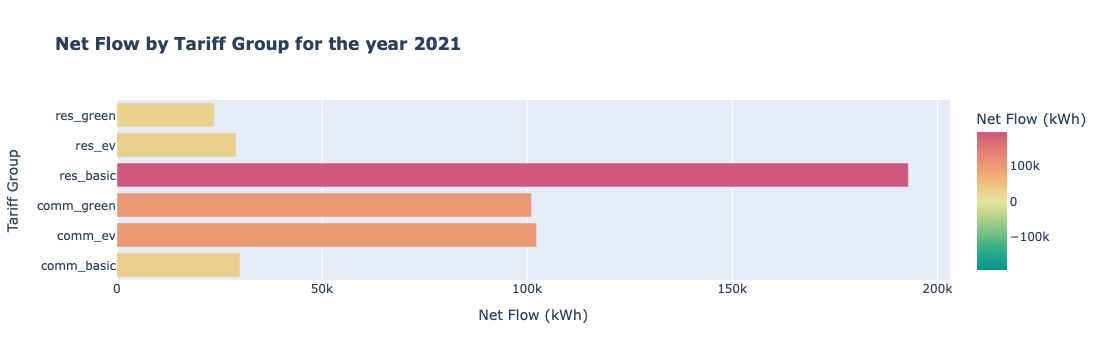

In [13]:
# Plot the results. 
fig = px.bar(df_tariff, x="net_kWh",  y="tariff_id", orientation="h", color="net_kWh",
             color_continuous_scale=px.colors.diverging.Temps, color_continuous_midpoint=0,
             title="<b>Net Flow by Tariff Group for the year {}<b>".format(year),
             labels={'tariff_id':'Tariff Group', 
                         'net_kWh': 'Net Flow (kWh)'})
fig.show()

Negative net flow indicates that production from DERs (in this case, solar panels) exceeds current consumption. 

---